In [11]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Library berhasil di-import!")

Library berhasil di-import!


## 1. Data Generation (Synthetic POS Data 360 Hari / 1 Tahun)

In [12]:
def generate_synthetic_pos_data(n_days=360):
    np.random.seed(42)
    
    # 1. Feature: is_hari_pasar (2/7 probabilitas)
    is_hari_pasar = np.random.choice([0, 1], size=n_days, p=[5/7, 2/7])
    
    # 2. Feature: is_tanggal_muda (tanggal 25 s.d. 5 bulan berikutnya)
    day_of_month = np.tile(np.arange(1, 31), n_days // 30 + 1)[:n_days]
    is_tanggal_muda = np.where((day_of_month >= 25) | (day_of_month <= 5), 1, 0)
    
    # 3. Feature: past_7day_avg (rata-rata penjualan 7 hari terakhir)
    past_7day_avg = np.random.normal(loc=5.5, scale=1.2, size=n_days)
    past_7day_avg = np.clip(past_7day_avg, 2.0, 12.0)
    
    # Matrix X
    X = np.column_stack((is_hari_pasar, is_tanggal_muda, past_7day_avg))
    
    # Target y (Daily Demand) dengan pola ekonomi + Noise
    baseline = 4.0
    pasar_effect = is_hari_pasar * 3.0
    payday_effect = is_tanggal_muda * 2.0
    noise = np.random.normal(0, 0.5, size=n_days)
    
    y = baseline + pasar_effect + payday_effect + (past_7day_avg * 0.2) + noise
    y = np.clip(y, 1.0, 15.0)
    
    return X, y

X, y = generate_synthetic_pos_data(360)
df = pd.DataFrame(X, columns=['is_hari_pasar', 'is_tanggal_muda', 'past_7day_avg'])
df['demand_aktual'] = y
df.head(10)

,is_hari_pasar,is_tanggal_muda,past_7day_avg,demand_aktual
0,0.0,1.0,7.403220,7.350848
1,1.0,1.0,4.014621,9.051353
2,1.0,1.0,8.059640,10.489056
3,0.0,1.0,3.157495,6.495137
4,0.0,1.0,5.317858,5.715128
5,0.0,0.0,6.205981,5.214049
6,0.0,0.0,5.837190,5.051971
7,1.0,0.0,4.752761,8.298655
8,0.0,0.0,5.250253,5.974529
9,0.0,0.0,4.908399,5.544962


## 2. Train-Test Split (80% Train, 20% Test)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ukuran Data Train : {X_train.shape[0]} baris")
print(f"Ukuran Data Test  : {X_test.shape[0]} baris")

Ukuran Data Train : 288 baris
Ukuran Data Test  : 72 baris


## 3. Training Model Random Forest Regressor

In [14]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Training selesai!")

Training selesai!


## 4. Evaluasi Metrik ML (MAE, RMSE, R² Score)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("=" * 45)
print("METRIK EVALUASI MODEL FITUR 1")
print("=" * 45)
print(f"  • MAE  (Mean Absolute Error) : {mae:.4f} unit")
print(f"  • RMSE (Root Mean Sq Error) : {rmse:.4f} unit")
print(f"  • MAPE (Mean Abs Pct Error) : {mape:.2f}%")
print(f"  • R² Score (Akurasi Pola)  : {r2 * 100:.2f}%")
print("=" * 45)

METRIK EVALUASI MODEL FITUR 1
  • MAE  (Mean Absolute Error) : 0.4224 unit
  • RMSE (Root Mean Sq Error) : 0.5433 unit
  • MAPE (Mean Abs Pct Error) : 6.11%
  • R² Score (Akurasi Pola)  : 90.21%


## 5. Visualisasi Grafik Hasil Evaluasi

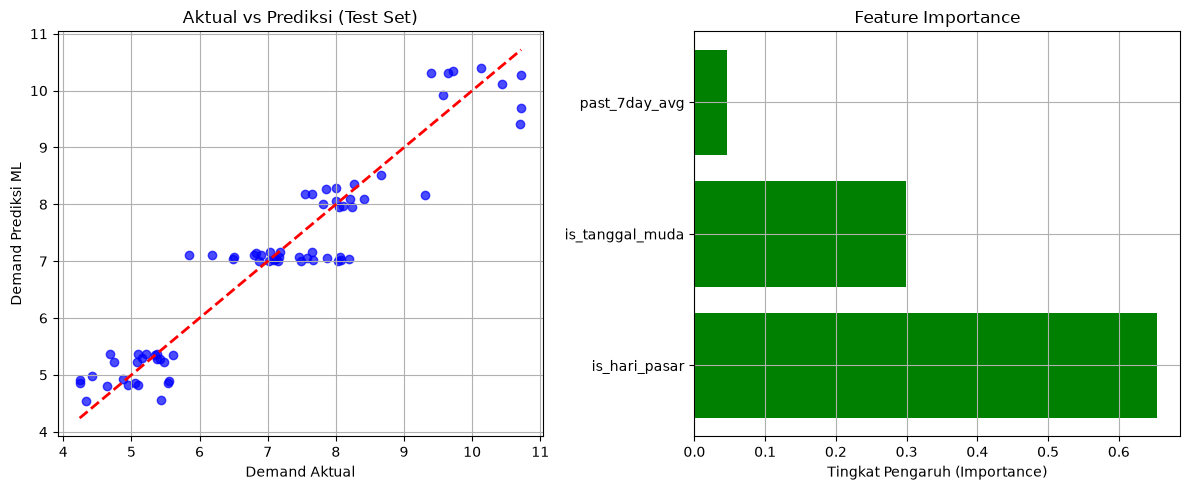

In [16]:
plt.figure(figsize=(12, 5))

# Plot 1: Prediksi vs Aktual
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Demand Aktual')
plt.ylabel('Demand Prediksi ML')
plt.title('Aktual vs Prediksi (Test Set)')
plt.grid(True)

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
feature_names = ['is_hari_pasar', 'is_tanggal_muda', 'past_7day_avg']
importances = rf_model.feature_importances_
plt.barh(feature_names, importances, color='green')
plt.xlabel('Tingkat Pengaruh (Importance)')
plt.title('Feature Importance')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Export Model Artifact ke `demand_rf_model.pkl`

In [17]:
import os
import joblib

# Simpan model langsung ke folder backend
target_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "apps", "backend", "app", "ml"))
if not os.path.exists(os.path.dirname(target_dir)):
    target_dir = os.path.abspath(os.path.join(os.getcwd(), "apps", "backend", "app", "ml"))

os.makedirs(target_dir, exist_ok=True)
export_path = os.path.join(target_dir, "demand_rf_model.pkl")
joblib.dump(rf_model, export_path)

print("Model artifact berhasil diexport!")
print(f"Lokasi file: {export_path}")

Model artifact berhasil diexport!
Lokasi file: c:\Users\rilob\KOMPETISI\dagangpintar-ai\apps\backend\app\ml\demand_rf_model.pkl
